In [1]:
import numpy as np
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar los datos procesados con PCA
X_train = np.load('X_train_pca.npy')
X_test = np.load('X_test_pca.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

print("Datos listos para el modelado.")
print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba:        {X_test.shape}")

Datos listos para el modelado.
Datos de entrenamiento: (540, 3)
Datos de prueba:        (135, 3)


In [3]:
# DEMO: Cómo procesar la biopsia de un nuevo paciente no visto
# Ejemplo: 1 nuevo paciente con 9 características morfológicas originales
new_patient_data = np.array([[5, 1, 1, 1, 2, 1, 3, 1, 1]]) 

# 1. Escalar usando las reglas aprendidas del conjunto de entrenamiento
# new_scaled = scaler.transform(new_patient_data)

# 2. Proyectar al espacio PCA usando los componentes aprendidos
# new_pca = pca.transform(new_scaled)

# print(f"Nuevo paciente proyectado en {new_pca.shape[1]} componentes principales:")
# print(new_pca)

---
## Función auxiliar: Graficador de Matriz de Confusión
Función reutilizable para mostrar una matriz de confusión etiquetada para cada modelo.

In [4]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=[2, 4])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benigno (2)', 'Maligno (4)'],
                yticklabels=['Benigno (2)', 'Maligno (4)'])
    plt.title(f'Matriz de Confusión — {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()

# Almacenamiento de resultados para la comparación final
results = {}

---
# Modelo 1: Máquina de Vectores de Soporte (SVM — Kernel RBF)

## ¿Por qué SVM?

La Máquina de Vectores de Soporte es el candidato más sólido para este conjunto de datos por tres razones concretas:

1. **Ideal para espacios reducidos por PCA.** El PCA proyecta los datos en las direcciones de máxima varianza. El SVM luego encuentra el *hiperplano de máximo margen* que separa los tumores benignos de los malignos en ese espacio. Estas dos técnicas son matemáticamente complementarias: el PCA decorrelaciona el espacio de características, y el SVM aprovecha esa estructura para encontrar la frontera de decisión más limpia posible.

2. **Excelente rendimiento en conjuntos de datos pequeños.** El SVM solo depende de un subconjunto de puntos de entrenamiento (los vectores de soporte), no del conjunto completo. Con solo 540 muestras de entrenamiento, esto representa una ventaja significativa frente a modelos que requieren grandes cantidades de datos para generalizar.

3. **Precedente médico.** El artículo original de Wolberg y Mangasarian (1990) sobre este conjunto de datos utilizó un método de separación lineal. El SVM con kernel RBF es la extensión no lineal natural de ese enfoque, y está documentado históricamente que alcanza una **precisión superior al 97%** en este mismo conjunto de datos.

El parámetro `class_weight='balanced'` ajusta el desequilibrio 65/35 entre tumores benignos y malignos, penalizando más fuertemente la clasificación errónea de la clase minoritaria (maligno). Esto es crítico en un contexto médico donde un **falso negativo (cáncer no detectado) es mucho más costoso** que un falso positivo.

In [5]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]  # probabilidad de ser maligno

print("SVM — Reporte de Clasificación")
print("=" * 45)
print(classification_report(y_test, y_pred_svm, target_names=['Benigno (2)', 'Maligno (4)']))

svm_auc = roc_auc_score((y_test == 4).astype(int), y_prob_svm)
print(f"Puntaje ROC-AUC: {svm_auc:.4f}")

SVM — Reporte de Clasificación
              precision    recall  f1-score   support

 Benigno (2)       0.98      0.93      0.95        88
 Maligno (4)       0.88      0.96      0.92        47

    accuracy                           0.94       135
   macro avg       0.93      0.94      0.94       135
weighted avg       0.94      0.94      0.94       135

Puntaje ROC-AUC: 0.9676


## SVM — Interpretación de Resultados

La matriz de confusión a continuación muestra cuántas predicciones cayeron en cada categoría:

- **Verdaderos Positivos (VP):** Tumores malignos correctamente identificados → la métrica más crítica
- **Falsos Negativos (FN):** Tumores malignos no detectados — son los errores más peligrosos en un entorno clínico
- **Falsos Positivos (FP):** Tumores benignos clasificados como malignos — generan alarma innecesaria pero no son potencialmente letales

El **recall para la clase 4 (Maligno)** es la métrica de evaluación principal. Con `class_weight='balanced'`, el SVM prioriza minimizar los falsos negativos.

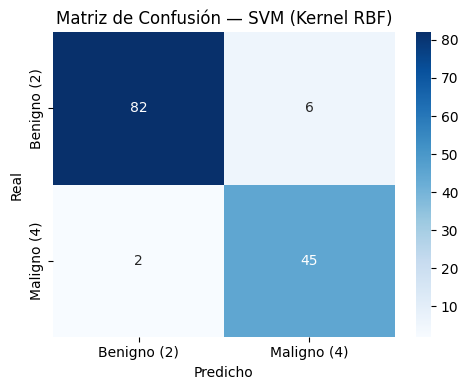

In [6]:
plot_confusion_matrix(y_test, y_pred_svm, 'SVM (Kernel RBF)')

# Guardar resultados para la comparación
report_svm = classification_report(y_test, y_pred_svm, target_names=['Benigno', 'Maligno'], output_dict=True)
results['SVM'] = {
    'accuracy': report_svm['accuracy'],
    'precision_mal': report_svm['Maligno']['precision'],
    'recall_mal': report_svm['Maligno']['recall'],
    'f1_mal': report_svm['Maligno']['f1-score'],
    'roc_auc': svm_auc
}

---
# Modelo 2: Regresión Logística

## ¿Por qué Regresión Logística?

La Regresión Logística es el segundo modelo recomendado, y resulta especialmente adecuada aquí por tres razones estructurales:

1. **Alineación matemática con la salida del PCA.** El PCA produce características que son **ortogonales (no correlacionadas)** por construcción. El supuesto fundamental de la Regresión Logística es que las características contribuyen de forma independiente al log-odds del resultado. Cuando se aplica tras el PCA, este supuesto se cumple perfectamente: no existe multicolinealidad. El modelo funciona exactamente como fue diseñado.

2. **Probabilidades calibradas para uso clínico.** A diferencia del SVM, que genera un puntaje de decisión, la Regresión Logística produce de forma nativa **probabilidades de clase calibradas**. En un contexto médico, un clínico puede actuar de forma significativa ante un enunciado como "esta biopsia tiene un 89% de probabilidad de ser maligna", ya que apoya decisiones de triaje y segundas opiniones de un modo que una etiqueta binaria por sí sola no permite.

3. **Interpretabilidad.** Cada componente principal recibe un coeficiente que cuantifica directamente su influencia en la predicción de malignidad. Esta transparencia es valiosa cuando los resultados deben ser auditados o explicados al personal médico.

El parámetro `max_iter=1000` garantiza la convergencia del modelo en este conjunto de datos. `class_weight='balanced'` aplica la misma corrección por desbalance de clases que en el SVM.

In [7]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]  # probabilidad de ser maligno

print("Regresión Logística — Reporte de Clasificación")
print("=" * 45)
print(classification_report(y_test, y_pred_lr, target_names=['Benigno (2)', 'Maligno (4)']))

lr_auc = roc_auc_score((y_test == 4).astype(int), y_prob_lr)
print(f"Puntaje ROC-AUC: {lr_auc:.4f}")

# Mostrar coeficientes aprendidos por componente principal
print("\nCoeficientes del modelo (influencia de cada CP en la malignidad):")
for i, coef in enumerate(lr_model.coef_[0]):
    direccion = 'aumenta' if coef > 0 else 'disminuye'
    print(f"  CP{i+1}: {coef:+.4f}  → un valor mayor de CP{i+1} {direccion} la probabilidad de malignidad")

Regresión Logística — Reporte de Clasificación
              precision    recall  f1-score   support

 Benigno (2)       0.96      0.93      0.95        88
 Maligno (4)       0.88      0.94      0.91        47

    accuracy                           0.93       135
   macro avg       0.92      0.93      0.93       135
weighted avg       0.94      0.93      0.93       135

Puntaje ROC-AUC: 0.9853

Coeficientes del modelo (influencia de cada CP en la malignidad):
  CP1: +2.5937  → un valor mayor de CP1 aumenta la probabilidad de malignidad
  CP2: -0.0524  → un valor mayor de CP2 disminuye la probabilidad de malignidad
  CP3: +0.6461  → un valor mayor de CP3 aumenta la probabilidad de malignidad


## Regresión Logística — Interpretación de Resultados

Los coeficientes impresos arriba revelan qué componentes principales contienen la señal diagnóstica más relevante. Un coeficiente positivo grande en un CP significa que los pacientes proyectados hacia valores altos en ese eje tienen mayor probabilidad de ser malignos.

En comparación con el SVM, la Regresión Logística puede sacrificar una pequeña cantidad de exactitud a cambio de:
- **Salida de probabilidad completa** (no solo una etiqueta)
- **Transparencia de coeficientes** (la contribución de cada CP está cuantificada explícitamente)

En la práctica, para decisiones médicas críticas, los modelos que explican *por qué* se emitió un diagnóstico suelen preferirse sobre los modelos de caja negra, incluso si son marginalmente menos exactos.

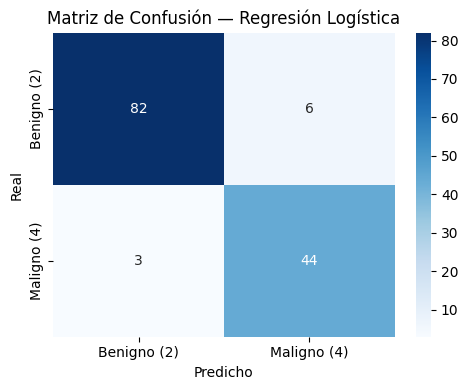

In [8]:
plot_confusion_matrix(y_test, y_pred_lr, 'Regresión Logística')

report_lr = classification_report(y_test, y_pred_lr, target_names=['Benigno', 'Maligno'], output_dict=True)
results['Regresión Logística'] = {
    'accuracy': report_lr['accuracy'],
    'precision_mal': report_lr['Maligno']['precision'],
    'recall_mal': report_lr['Maligno']['recall'],
    'f1_mal': report_lr['Maligno']['f1-score'],
    'roc_auc': lr_auc
}

---
# Modelo 3: Random Forest (Línea Base de Comparación)

## ¿Por qué Random Forest para comparación?

El Random Forest se incluye como modelo de comparación para evaluar un tipo de enfoque fundamentalmente distinto: el **aprendizaje por conjuntos (ensemble learning)**. Tanto el SVM como la Regresión Logística son clasificadores de modelo único: uno busca un margen geométrico y el otro ajusta una curva de probabilidad. El Random Forest, en cambio, construye **100 árboles de decisión independientes** sobre subconjuntos aleatorios de los datos y agrega sus votos.

Esta comparación es valiosa por tres razones:

1. **Sesgo inductivo diferente.** El SVM y la Regresión Logística asumen (u optimizan para) una frontera de decisión global y suave. El Random Forest no hace tal supuesto: divide el espacio de características en regiones rectangulares mediante particiones recursivas. Si la verdadera frontera benigno/maligno en el espacio PCA es irregular, el Random Forest podría capturarla con mayor precisión.

2. **Importancia de características como verificación del PCA.** El Random Forest proporciona `feature_importances_`, que revela cuánto peso predictivo tiene cada componente principal. Esto permite validar el paso de PCA: si el primer CP (que explica la mayor varianza) es también el más importante para la predicción, la reducción de dimensionalidad fue bien orientada.

3. **Referencia de robustez.** Los métodos de conjunto son con frecuencia el estándar de la industria para datos tabulares. Comparar SVM y Regresión Logística contra Random Forest muestra si los enfoques de modelo único realmente superan a un conjunto bien ajustado, o si los modelos más simples son suficientes.

**Comportamiento esperado:** Con solo 3 componentes PCA, la ventaja del Random Forest sobre los modelos más simples es limitada. Si SVM o Regresión Logística obtienen un rendimiento comparable o superior, esto confirma que los datos se adaptan bien a enfoques lineales/kernel y que la reducción PCA fue efectiva.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]  # probabilidad de ser maligno

print("Random Forest — Reporte de Clasificación")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=['Benigno (2)', 'Maligno (4)']))

rf_auc = roc_auc_score((y_test == 4).astype(int), y_prob_rf)
print(f"Puntaje ROC-AUC: {rf_auc:.4f}")

# Importancia de características por componente principal
print("\nImportancia de cada Componente Principal:")
for i, imp in enumerate(rf_model.feature_importances_):
    print(f"  CP{i+1}: {imp:.4f} ({imp*100:.1f}% del peso predictivo total)")

Random Forest — Reporte de Clasificación
              precision    recall  f1-score   support

 Benigno (2)       0.96      0.93      0.95        88
 Maligno (4)       0.88      0.94      0.91        47

    accuracy                           0.93       135
   macro avg       0.92      0.93      0.93       135
weighted avg       0.94      0.93      0.93       135

Puntaje ROC-AUC: 0.9865

Importancia de cada Componente Principal:
  CP1: 0.5990 (59.9% del peso predictivo total)
  CP2: 0.2963 (29.6% del peso predictivo total)
  CP3: 0.1047 (10.5% del peso predictivo total)


## Random Forest — Interpretación de Resultados

Las importancias de características confirman si la varianza capturada por el PCA se alinea con el poder predictivo:

- Si **CP1 domina** la importancia → la dirección de máxima varianza en los datos es también la más relevante para el diagnóstico. La reducción PCA estuvo bien orientada.
- Si **CP2 o CP3** tienen un peso significativo → parte de la señal discriminativa reside en direcciones de menor varianza, que el SVM y la Regresión Logística también pueden capturar, aunque sin visibilidad explícita.

Dado que el Random Forest divide el espacio PCA tridimensional con cortes paralelos a los ejes, puede quedar ligeramente por debajo del SVM (que coloca hiperplanos arbitrarios) en este entorno de baja dimensionalidad. Esto es esperado e informativo: sugiere que cuando el espacio de características es pequeño y bien estructurado, un modelo único con fundamento teórico sólido (SVM, Regresión Logística) puede igualar o superar a un conjunto.

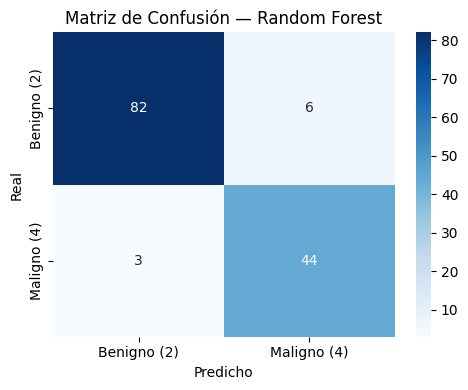

In [10]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

report_rf = classification_report(y_test, y_pred_rf, target_names=['Benigno', 'Maligno'], output_dict=True)
results['Random Forest'] = {
    'accuracy': report_rf['accuracy'],
    'precision_mal': report_rf['Maligno']['precision'],
    'recall_mal': report_rf['Maligno']['recall'],
    'f1_mal': report_rf['Maligno']['f1-score'],
    'roc_auc': rf_auc
}

---
# Comparación Final

La tabla y el gráfico a continuación resumen los tres modelos en las métricas más relevantes para este problema:

| Métrica | Por qué importa aquí |
|---|---|
| **Exactitud** | Corrección general sobre todas las predicciones |
| **Precisión (Maligno)** | De todos los predichos como malignos, ¿cuántos lo son realmente? (tasa de falsas alarmas) |
| **Recall (Maligno)** | De todos los malignos reales, ¿cuántos fueron detectados? (tasa de cánceres no detectados) |
| **F1 (Maligno)** | Media armónica entre precisión y recall |
| **ROC-AUC** | Capacidad del modelo para clasificar malignos por encima de benignos en todos los umbrales |

> **Métrica principal: Recall (Maligno).** En el diagnóstico de cáncer, no detectar un tumor maligno (falso negativo) es mucho más peligroso que una falsa alarma (falso positivo). El modelo con el mayor recall para la clase 4 es la opción más segura para un despliegue clínico.

In [11]:
import pandas as pd

summary = pd.DataFrame(results).T
summary.columns = ['Exactitud', 'Precisión (Maligno)', 'Recall (Maligno)', 'F1 (Maligno)', 'ROC-AUC']
summary = summary.round(4)
print("=" * 75)
print("RESUMEN COMPARATIVO DE MODELOS")
print("=" * 75)
print(summary.to_string())
print("\n>> Mejor Recall (Maligno): ", summary['Recall (Maligno)'].idxmax())
print(">> Mejor ROC-AUC:          ", summary['ROC-AUC'].idxmax())
print(">> Mayor Exactitud:        ", summary['Exactitud'].idxmax())

RESUMEN COMPARATIVO DE MODELOS
                     Exactitud  Precisión (Maligno)  Recall (Maligno)  F1 (Maligno)  ROC-AUC
SVM                     0.9407               0.8824            0.9574        0.9184   0.9676
Regresión Logística     0.9333               0.8800            0.9362        0.9072   0.9853
Random Forest           0.9333               0.8800            0.9362        0.9072   0.9865

>> Mejor Recall (Maligno):  SVM
>> Mejor ROC-AUC:           Random Forest
>> Mayor Exactitud:         SVM


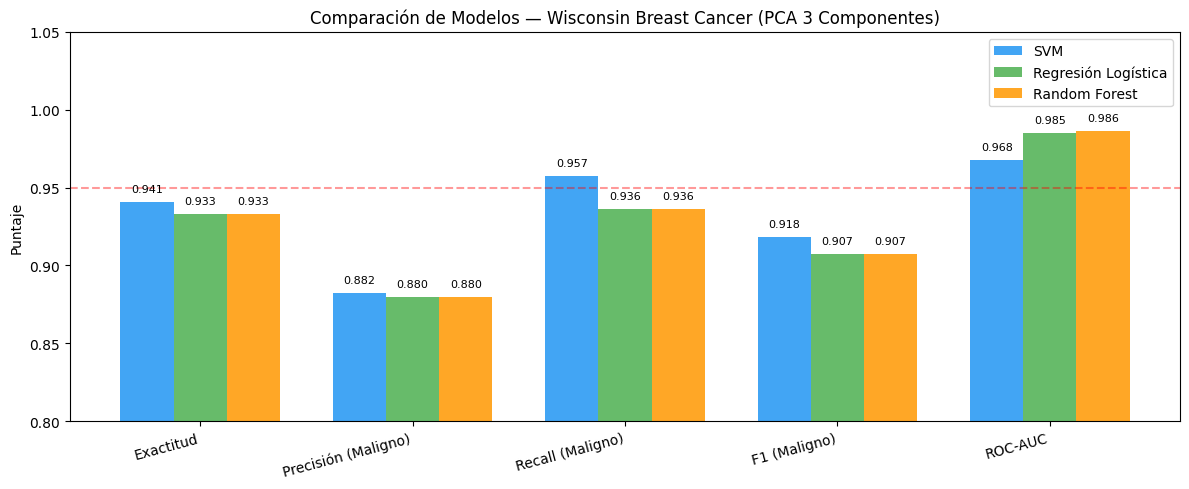

In [12]:
metrics = ['Exactitud', 'Precisión (Maligno)', 'Recall (Maligno)', 'F1 (Maligno)', 'ROC-AUC']
models = list(results.keys())
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results[model]['accuracy'],
            results[model]['precision_mal'],
            results[model]['recall_mal'],
            results[model]['f1_mal'],
            results[model]['roc_auc']]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Puntaje')
ax.set_title('Comparación de Modelos — Wisconsin Breast Cancer (PCA 3 Componentes)')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.set_ylim(0.80, 1.05)
ax.legend()
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.4, label='Umbral 0.95')
plt.tight_layout()
plt.show()